# Step 1 - Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from xgboost import XGBRegressor

print("Imports OK")

Imports OK


# Step 2 - Configurartion

In [2]:
split_dir  = Path("../data/split")
output_dir = Path("../data/results")

nintervals   = 96
random_state = 42

features = [
    "price_lag1d",
    "price_lag7d",
    "price_hourly_lag1d",
    "price_hourly_lag7d",
    "wind_mwh",
    "solar_mwh",
    "load_mwh",
]

target     = "price_eur_mwh"
n_features = len(features)

# rolling window adapted from Lebedev paper (1461, 1092, 84, 56)
# to fit the 100 days post-reform training set
windows = [100, 84, 56, 28]

print(f"Interval  : {nintervals}")
print(f"Features  : {n_features}")
print(f"Windows   : {windows} days")

Interval  : 96
Features  : 7
Windows   : [100, 84, 56, 28] days


# Step 3 - Load and Reshape data

In [3]:
df = pd.read_csv(split_dir / "feature_matrix_clean.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)   #sort the  data by time and then renumber 

train_days = [pd.Timestamp(d).date() for d in pd.read_csv(split_dir / "train_days.csv")["date"]]
test_days  = [pd.Timestamp(d).date() for d in pd.read_csv(split_dir / "test_days.csv")["date"]]
all_days   = sorted(df["timestamp"].dt.date.unique())

n_train = len(train_days)   # 100
n_test  = len(test_days)    # 44
n_total = len(all_days)     # 144

# interval-level arrays (one row per quarter-hour)
X_all = df[features].values                 
y_all = df[target].values

# day-level index: row i starts at i * nintervals
print(f"X_all shape : {X_all.shape}  (intervals, features)")
print(f"y_all shape : {y_all.shape}  (intervals,)")
print(f"Train       : {n_train} days = rows 0 to {n_train * nintervals - 1}")
print(f"Test        : {n_test} days  = rows {n_train * nintervals} to {n_total * nintervals - 1}")

X_all shape : (13824, 7)  (intervals, features)
y_all shape : (13824,)  (intervals,)
Train       : 100 days = rows 0 to 9599
Test        : 44 days  = rows 9600 to 13823


# Step 4- Normalisation
Mean-std standardisation using training data statistics only(Lebedev et al. `standardization_case='mean_std'`)

In [4]:
# training interval rows
train_end = n_train * nintervals
X_train_raw = X_all[:train_end, :]
y_train_raw = y_all[:train_end]

# compute statistics on training data only
offset_X = X_train_raw.mean(axis=0)
scale_X  = X_train_raw.std(axis=0)
scale_X[scale_X == 0] = 1.0

offset_y = float(y_train_raw.mean())
scale_y  = float(y_train_raw.std())

# Normalise
X_norm = (X_all - offset_X) / scale_X
y_norm = (y_all - offset_y) / scale_y

print(f"offset_y (mean price) : {offset_y:.4f} EUR/MWh")
print(f"scale_y  (std price)  : {scale_y:.4f} EUR/MWh")
print(f"Training rows         : {train_end}")
print(f"Test rows             : {n_test * nintervals}")

offset_y (mean price) : 95.2633 EUR/MWh
scale_y  (std price)  : 43.5266 EUR/MWh
Training rows         : 9600
Test rows             : 4224


# Step 5- XGBoost Hyperparameters
taken directly from the Optuna run in Lebdev et al., notebook name : XgBoost.py

In [5]:
# Optuna-tuned hyperparameters from Lebedev et al. (2025), seed 42
XGB_PARAMS = dict(
    n_estimators     = 444,
    learning_rate    = 0.020834136992346326,
    max_depth        = 4,
    min_child_weight = 6,
    subsample        = 0.6646124229308177,
    colsample_bytree = 0.6061035603483517,
    gamma            = 0.008910429703573388,
    reg_alpha        = 0.14968119527801219,
    reg_lambda       = 0.26277200687034197,
    random_state     = random_state,
)

print("XGBoost hyperparameters (Lebedev et al. 2025):")
for k, v in XGB_PARAMS.items():
    print(f"  {k:<22}: {v}")

XGBoost hyperparameters (Lebedev et al. 2025):
  n_estimators          : 444
  learning_rate         : 0.020834136992346326
  max_depth             : 4
  min_child_weight      : 6
  subsample             : 0.6646124229308177
  colsample_bytree      : 0.6061035603483517
  gamma                 : 0.008910429703573388
  reg_alpha             : 0.14968119527801219
  reg_lambda            : 0.26277200687034197
  random_state          : 42


# Step 6 - Rolling Window Evaluation

In [7]:
# storage: shape (n_test, nintervals) per window
xgb_pred_windows = {w: np.zeros((n_test, nintervals)) for w in windows}

for w in windows:
    print(f"Window {w:>3d} days ...", end=" ", flush=True)
    for i in range(n_test):
        # Row indices in the interval-level array
        oben_day  = n_train + i          # forecast day index (0-based)
        unten_day = max(oben_day - w, 0) # first day of window

        # Convert day indices to interval row indices
        row_start = unten_day * nintervals
        row_end   = oben_day  * nintervals   # exclusive — up to but not including forecast day
        row_pred  = oben_day  * nintervals   # first interval of forecast day

        # Train on window intervals, predict forecast day intervals
        model = XGBRegressor(**XGB_PARAMS)
        model.fit(X=X_norm[row_start:row_end, :],y=y_norm[row_start:row_end],)
        xgb_pred_windows[w][i, :] = model.predict(X=X_norm[row_pred:row_pred + nintervals, :])

    # MAE per window (de-normalised)
    y_test_norm = y_norm[n_train * nintervals:].reshape(n_test, nintervals)
    errors = (y_test_norm - xgb_pred_windows[w]) * scale_y
    mae_w  = float(np.mean(np.abs(errors)))
    print(f"MAE = {mae_w:.4f} EUR/MWh")

print("\nAll windows done.")

Window 100 days ... MAE = 11.8362 EUR/MWh
Window  84 days ... MAE = 11.5676 EUR/MWh
Window  56 days ... MAE = 12.4815 EUR/MWh
Window  28 days ... MAE = 12.5606 EUR/MWh

All windows done.


# Step 7 - Average and Evaluate

In [9]:
# Final forecast: average of 4 windows (Lebedev et al.)
xgb_pred_mean = np.mean([xgb_pred_windows[w] for w in windows], axis=0)

# Actual test prices (de-normalised)
y_test_norm = y_norm[n_train * nintervals:].reshape(n_test, nintervals)
y_test_orig = y_test_norm * scale_y + offset_y
y_pred_orig = xgb_pred_mean * scale_y + offset_y

# MAE
errors = y_test_orig - y_pred_orig
mae    = float(np.mean(np.abs(errors)))


print("  XGBoost — Test Set Results")
print(f"  MAE : {mae:.4f} EUR/MWh")


print("\nPer-window MAE:")
for w in windows:
    e = (y_test_norm - xgb_pred_windows[w]) * scale_y
    print(f"  Window {w:>3d} days: {np.mean(np.abs(e)):.4f} EUR/MWh")

  XGBoost — Test Set Results
  MAE : 11.5659 EUR/MWh

Per-window MAE:
  Window 100 days: 11.8362 EUR/MWh
  Window  84 days: 11.5676 EUR/MWh
  Window  56 days: 12.4815 EUR/MWh
  Window  28 days: 12.5606 EUR/MWh


# Step 8 - Forecast Plot

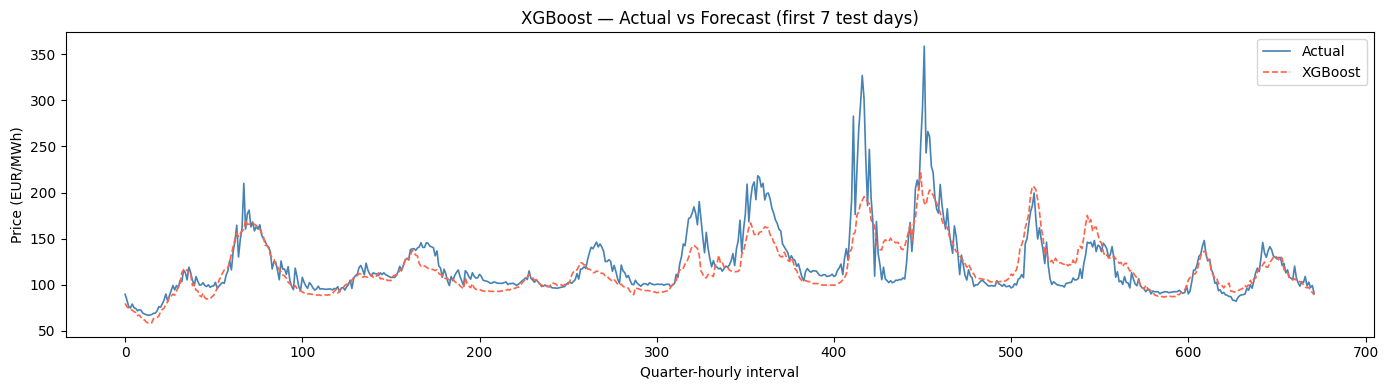

plot saved


In [10]:
n_days = 7
n_plot = n_days * nintervals

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test_orig.flatten()[:n_plot], label="Actual",  linewidth=1.2, color="steelblue")
ax.plot(y_pred_orig.flatten()[:n_plot], label="XGBoost", linewidth=1.2, color="tomato", linestyle="--")
ax.set_title("XGBoost — Actual vs Forecast (first 7 test days)")
ax.set_xlabel("Quarter-hourly interval")
ax.set_ylabel("Price (EUR/MWh)")
ax.legend()
plt.tight_layout()
plt.savefig(output_dir / "XGBoost_forecast_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("plot saved")

# Step 9 - Save Results

In [11]:
xgb_dict = {
    "model_name"   : "XGBoost",
    "prediction"   : y_pred_orig,
    "y_test"       : y_test_orig,
    "offset"       : offset_y,
    "scale"        : scale_y,
    "mae"          : mae,
    "pred_windows" : {w: xgb_pred_windows[w] * scale_y + offset_y for w in windows},
}

with open(output_dir / "XGBoost.pkl", "wb") as f:
    pickle.dump([xgb_dict], f)

print(f"Saved: {output_dir / 'XGBoost.pkl'}")
print("XGBoost.ipynb complete")

Saved: ..\data\results\XGBoost.pkl
XGBoost.ipynb complete
